# SSN calculator: one image, step by step

Этот ноутбук нужен как ручной калькулятор для SuperSimpleNet: берем одну картинку MVTec, прогоняем через preprocessing, `feature_extractor`, `adaptor`, `segdec`, смотрим raw logits, sigmoid-карту и итоговый image score.

Важно: он не запускает обучение. Цель - проверить, что inference path и training loss path в основном ноутбуке используют модель одинаково и что `sigmoid` применяется только как перевод logits в probability-like карту для метрик/визуализации.

## 0. Environment check

Запускай ноутбук kernel'ом из `my_env`. Если `torch` или `anomalib` не находятся, выполни следующую install-ячейку. Для GPU нужна именно CUDA-сборка PyTorch: в проверке ниже версия должна выглядеть как `2.7.1+cu128`, а `torch.cuda.is_available()` должен быть `True`.

In [1]:
# Run this cell only if imports fail in my_env.
# CUDA 12.8 PyTorch build:
# %pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu128
#
# Project/runtime dependencies:
# %pip install anomalib matplotlib numpy scikit-learn scikit-image opencv-python tqdm pillow

In [2]:
import importlib.util
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)

for package in ["torch", "torchvision", "anomalib", "numpy", "PIL"]:
    print(f"{package:12s}", "OK" if importlib.util.find_spec(package) else "MISSING")

import torch

print("torch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device:", torch.cuda.get_device_name(0))

assert "+cu128" in torch.__version__, "Expected CUDA 12.8 PyTorch wheel, e.g. torch==2.7.1+cu128"
assert torch.cuda.is_available(), "PyTorch is installed, but CUDA is not visible from this kernel"

Python executable: c:\Users\AERO\Desktop\master_work\Experiments\.venv\Scripts\python.exe
Python version: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
torch        OK
torchvision  OK
anomalib     OK
numpy        OK
PIL          OK
torch: 2.7.1+cu128
torch.version.cuda: 12.8
cuda available: True
cuda device: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as torch_f
from PIL import Image
from torchvision import transforms

from anomalib.models.image.supersimplenet.torch_model import SupersimplenetModel

c:\Users\AERO\Desktop\master_work\Experiments\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dataset_path = Path("../datasets/MVTecAD")
class_name = "hazelnut"
image_size = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

# Existing baseline checkpoint. Change this if you want to inspect another run.
model_path = Path("../experiments") / class_name / "ssn_baseline" / "try_1" / "trained_model.pth"

# Prefer a normal image because suspicious normal maps were the original symptom.
preferred_image = dataset_path / class_name / "test" / "good" / "000.png"
if preferred_image.exists():
    image_path = preferred_image
else:
    image_path = next((dataset_path / class_name / "test").glob("*/*.png"))

print(f"device: {device}")
print(f"model_path: {model_path.resolve()}")
print(f"image_path: {image_path.resolve()}")

device: cuda
model_path: C:\Users\AERO\Desktop\master_work\Experiments\experiments\hazelnut\ssn_baseline\try_1\trained_model.pth
image_path: C:\Users\AERO\Desktop\master_work\Experiments\datasets\MVTecAD\hazelnut\test\good\000.png


In [5]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
denormalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

image_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    normalize,
])


def summarize_tensor(name, tensor):
    x = tensor.detach().float().cpu()
    print(
        f"{name:24s} shape={tuple(x.shape)} "
        f"min={x.min().item(): .6f} max={x.max().item(): .6f} "
        f"mean={x.mean().item(): .6f} std={x.std(unbiased=False).item(): .6f}"
    )


def img2mask(img):
    mask = img.detach().cpu() if isinstance(img, torch.Tensor) else img
    mask = mask if mask.ndim <= 2 else mask.squeeze()
    if mask.ndim == 3:
        mask = mask[0]
    if mask.ndim != 2:
        raise ValueError(f"Expected 2D map, got {tuple(mask.shape)}")
    return mask


def upsample_map(anomaly_map, true_img_size):
    while anomaly_map.ndim < 4:
        anomaly_map = anomaly_map.unsqueeze(0)
    return torch_f.interpolate(anomaly_map, size=true_img_size, mode="bilinear", align_corners=False).squeeze()

## 1. Load and preprocess one image

raw PIL size             shape=(2,) min= 1024.000000 max= 1024.000000 mean= 1024.000000 std= 0.000000
input_tensor             shape=(3, 256, 256) min=-1.569912 max= 1.289922 mean=-1.041747 std= 0.416573
batch                    shape=(1, 3, 256, 256) min=-1.569912 max= 1.289922 mean=-1.041747 std= 0.416573


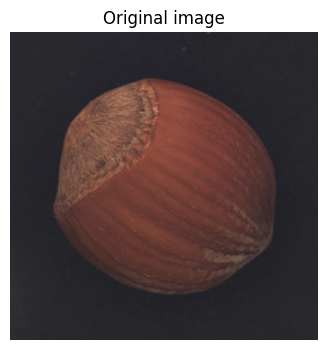

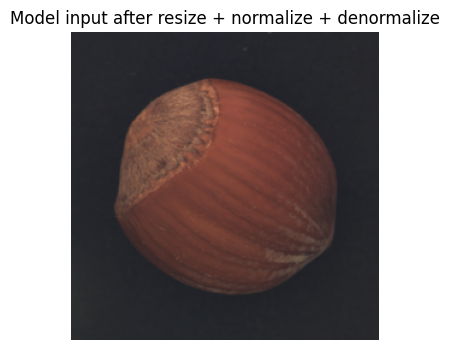

In [6]:
pil_image = Image.open(image_path).convert("RGB")
input_tensor = image_transform(pil_image)
batch = input_tensor.unsqueeze(0).to(device)

summarize_tensor("raw PIL size", torch.tensor(pil_image.size))
summarize_tensor("input_tensor", input_tensor)
summarize_tensor("batch", batch)

plt.figure(figsize=(4, 4))
plt.imshow(pil_image)
plt.title("Original image")
plt.axis("off")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(transforms.ToPILImage()(torch.clamp(denormalize(input_tensor.cpu()), 0, 1)))
plt.title("Model input after resize + normalize + denormalize")
plt.axis("off")
plt.show()

## 2. Load trained model

In [7]:
model = torch.load(model_path, map_location=device, weights_only=False)
model = model.to(device)
model.eval()

print(type(model))
print(f"feature_extractor: {type(model.feature_extractor).__name__}")
print(f"adaptor: {type(model.adaptor).__name__}")
print(f"segdec: {type(model.segdec).__name__}")

<class 'anomalib.models.image.supersimplenet.torch_model.SupersimplenetModel'>
feature_extractor: UpscalingFeatureExtractor
adaptor: FeatureAdapter
segdec: SegmentationDetectionModule


## 3. Standard inference path

`output.anomaly_map` и `output.pred_score` - raw logits. Для pixel metrics и картинки дальше используем `sigmoid(anomaly_map)`. Для ROC AUC image-level raw score можно оставлять raw, потому что ROC AUC инвариантен к монотонному sigmoid.

In [8]:
with torch.no_grad():
    output = model(batch)
    raw_anomaly_map = output.anomaly_map
    prob_anomaly_map = torch.sigmoid(raw_anomaly_map)
    raw_pred_score = output.pred_score.detach().view(-1)[0]
    prob_pred_score = torch.sigmoid(raw_pred_score)

summarize_tensor("raw_anomaly_map", raw_anomaly_map)
summarize_tensor("sigmoid_anomaly_map", prob_anomaly_map)
summarize_tensor("raw_pred_score", raw_pred_score)
summarize_tensor("sigmoid_pred_score", prob_pred_score)

raw_anomaly_map          shape=(1, 1, 256, 256) min=-2.113660 max= 1.627233 mean=-1.139834 std= 0.487268
sigmoid_anomaly_map      shape=(1, 1, 256, 256) min= 0.107776 max= 0.835790 mean= 0.252321 std= 0.093913
raw_pred_score           shape=() min=-1.537911 max=-1.537911 mean=-1.537911 std= 0.000000
sigmoid_pred_score       shape=() min= 0.176839 max= 0.176839 mean= 0.176839 std= 0.000000


## 4. Internal modules, inference-like path

Этот блок проверяет, что `model(batch)` действительно проходит через ожидаемые части: feature extractor, adaptor, segmentation/detection head.

Важная деталь: `model.segdec(adapted)` возвращает карту в feature-разрешении, например `64x64`, а публичный `model(batch).anomaly_map` в anomalib пропускает ее через `model.anomaly_map_generator(..., final_size=output_size)`. Поэтому для ручной проверки надо использовать именно этот generator, а не простой bilinear resize.

In [9]:
import inspect

print(inspect.getsource(type(model).forward))


    def forward(
        self,
        images: torch.Tensor,
        masks: torch.Tensor | None = None,
        labels: torch.Tensor | None = None,
    ) -> InferenceBatch | tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """SuperSimpleNet forward pass.

        Extract and process features, adapt them, generate anomalies (train only) and predict anomaly map and score.

        Args:
            images (torch.Tensor): Input images.
            masks (torch.Tensor): GT masks.
            labels (torch.Tensor): GT labels.

        Returns:
            inference: anomaly map and score
            training: anomaly map, score and GT masks and labels
        """
        output_size = images.shape[-2:]

        features = self.feature_extractor(images)
        adapted = self.adaptor(features)

        if self.training:
            masks = self.downsample_mask(masks, *features.shape[-2:])
            # make linter happy :)
            if labels is not None:
            

In [10]:
with torch.no_grad():
    output_size = batch.shape[-2:]
    features = model.feature_extractor(batch)
    adapted = model.adaptor(features)
    pred_map_from_modules, pred_score_from_modules = model.segdec(adapted)
    pred_map_from_generator = model.anomaly_map_generator(
        pred_map_from_modules,
        final_size=output_size,
    )

summarize_tensor("features", features)
summarize_tensor("adapted", adapted)
summarize_tensor("module_pred_map", pred_map_from_modules)
summarize_tensor("generator_pred_map", pred_map_from_generator)
summarize_tensor("module_pred_score", pred_score_from_modules)

raw_map_2d = img2mask(raw_anomaly_map)
generator_map_2d = img2mask(pred_map_from_generator)
print("Max |model.anomaly_map - generator_pred_map|:", (raw_map_2d - generator_map_2d).abs().max().item())
print("Max |model.pred_score - module_pred_score|:", (output.pred_score - pred_score_from_modules).abs().max().item())

features                 shape=(1, 1536, 64, 64) min= 0.000000 max= 2.265861 mean= 0.059389 std= 0.095347
adapted                  shape=(1, 1536, 64, 64) min=-0.512625 max= 0.515359 mean=-0.004113 std= 0.093409
module_pred_map          shape=(1, 1, 64, 64) min=-2.295557 max= 2.664463 mean=-1.140362 std= 0.533267
generator_pred_map       shape=(1, 1, 256, 256) min=-2.113660 max= 1.627233 mean=-1.139834 std= 0.487268
module_pred_score        shape=() min=-1.537911 max=-1.537911 mean=-1.537911 std= 0.000000
Max |model.anomaly_map - generator_pred_map|: 0.0
Max |model.pred_score - module_pred_score|: 0.0


## 5. Training loss path with synthetic normal target

SuperSimpleNet обучается на normal images, а синтетические аномалии создает `model.anomaly_generator`. Этот блок временно переводит модель в `train()`, потому что generator может зависеть от training/eval режима. После проверки исходный режим модели восстанавливается.

Если на одном trial synthetic mask остается нулевой, это еще не обязательно баг: generator стохастический. Поэтому ниже есть несколько trials и summary по `mask_sum`/`label`.

In [11]:
was_training = model.training
model.train()

try:
    with torch.no_grad():
        dummy_masks = torch.zeros((batch.shape[0], batch.shape[-2], batch.shape[-1]), device=device)
        dummy_labels = torch.zeros((batch.shape[0],), device=device)

        train_features = model.feature_extractor(batch)
        train_adapted = model.adaptor(train_features)
        target_mask = model.downsample_mask(dummy_masks, *train_features.shape[-2:])
        target_label = dummy_labels.to(torch.float32)
        generated_features, generated_mask, generated_label = model.anomaly_generator(
            train_adapted,
            target_mask,
            target_label,
        )
        train_pred_map, train_pred_score = model.segdec(generated_features)
finally:
    model.train(was_training)

summarize_tensor("dummy_masks", dummy_masks)
summarize_tensor("target_mask", target_mask)
summarize_tensor("generated_features", generated_features)
summarize_tensor("generated_mask", generated_mask)
summarize_tensor("generated_label", generated_label)
summarize_tensor("train_pred_map", train_pred_map)
summarize_tensor("train_pred_score", train_pred_score)

print("generated mask sum per sample:", generated_mask.flatten(1).sum(dim=1).detach().cpu().tolist())
print("generated labels:", generated_label.detach().cpu().tolist())

# Repeat the stochastic generator a few times to see whether synthetic anomalies are actually sampled.
trial_rows = []
was_training = model.training
model.train()
try:
    with torch.no_grad():
        for trial in range(10):
            features_t = model.feature_extractor(batch)
            adapted_t = model.adaptor(features_t)
            target_mask_t = model.downsample_mask(dummy_masks, *features_t.shape[-2:])
            generated_features_t, generated_mask_t, generated_label_t = model.anomaly_generator(
                adapted_t,
                target_mask_t,
                target_label,
            )
            trial_rows.append({
                "trial": trial,
                "batch": int(generated_mask_t.shape[0]),
                "mask_sum": [float(v) for v in generated_mask_t.flatten(1).sum(dim=1).detach().cpu()],
                "labels": [float(v) for v in generated_label_t.detach().cpu()],
            })
finally:
    model.train(was_training)

for row in trial_rows:
    print(row)

dummy_masks              shape=(1, 256, 256) min= 0.000000 max= 0.000000 mean= 0.000000 std= 0.000000
target_mask              shape=(1, 1, 64, 64) min= 0.000000 max= 0.000000 mean= 0.000000 std= 0.000000
generated_features       shape=(2, 1536, 64, 64) min=-0.512625 max= 0.515359 mean=-0.004113 std= 0.093409
generated_mask           shape=(2, 1, 64, 64) min= 0.000000 max= 0.000000 mean= 0.000000 std= 0.000000
generated_label          shape=(2,) min= 0.000000 max= 0.000000 mean= 0.000000 std= 0.000000
train_pred_map           shape=(2, 1, 64, 64) min=-1.983377 max= 3.373869 mean=-0.625000 std= 0.608362
train_pred_score         shape=(2,) min= 2.669507 max= 2.669507 mean= 2.669507 std= 0.000000
generated mask sum per sample: [0.0, 0.0]
generated labels: [0.0, 0.0]
{'trial': 0, 'batch': 2, 'mask_sum': [1128.0, 0.0], 'labels': [1.0, 0.0]}
{'trial': 1, 'batch': 2, 'mask_sum': [1059.0, 0.0], 'labels': [1.0, 0.0]}
{'trial': 2, 'batch': 2, 'mask_sum': [0.0, 0.0], 'labels': [0.0, 0.0]}
{'trial

## 6. Upsampling and visualization

Здесь шкала heatmap фиксирована в 0..1. Это важно: без `vmin=0, vmax=1` matplotlib растягивает любую слабую карту до яркой картинки, и normal image может визуально выглядеть аномальным.

prob_map_256             shape=(256, 256) min= 0.107776 max= 0.835790 mean= 0.252321 std= 0.093913
prob_map_original        shape=(1024, 1024) min= 0.107815 max= 0.835478 mean= 0.252321 std= 0.093862


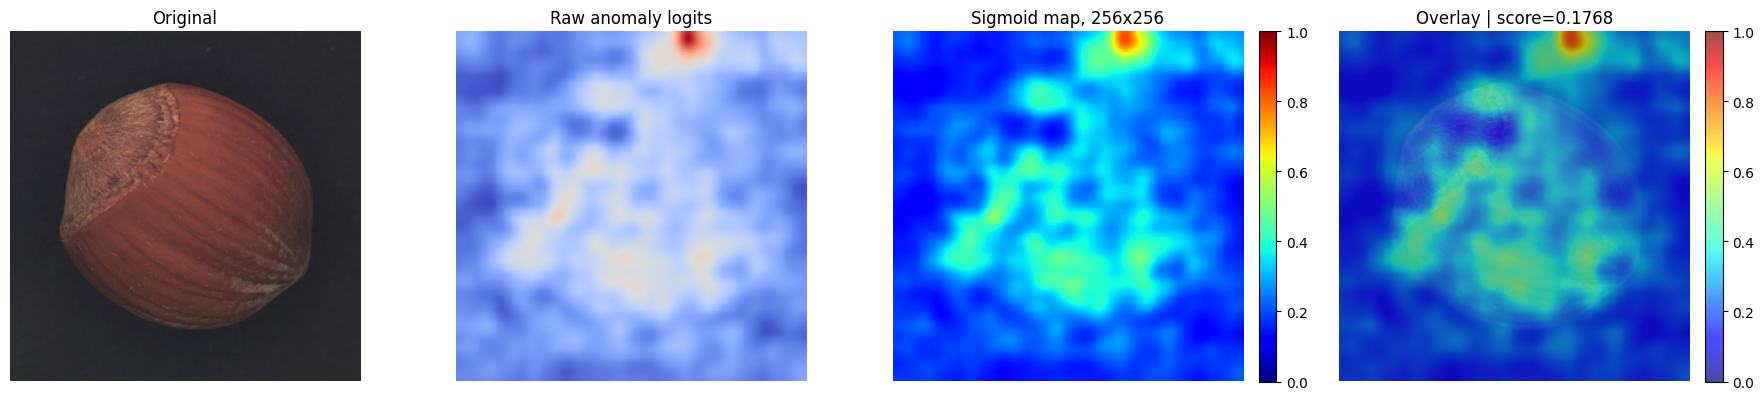

In [12]:
prob_map_256 = img2mask(prob_anomaly_map)
prob_map_original = upsample_map(prob_anomaly_map, true_img_size=(pil_image.height, pil_image.width))

summarize_tensor("prob_map_256", prob_map_256)
summarize_tensor("prob_map_original", prob_map_original)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(pil_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img2mask(raw_anomaly_map).cpu(), cmap="coolwarm")
axes[1].set_title("Raw anomaly logits")
axes[1].axis("off")

heat = axes[2].imshow(prob_map_256.cpu(), cmap="jet", vmin=0.0, vmax=1.0)
axes[2].set_title("Sigmoid map, 256x256")
axes[2].axis("off")
plt.colorbar(heat, ax=axes[2], fraction=0.046, pad=0.04)

axes[3].imshow(pil_image)
heat = axes[3].imshow(prob_map_original.cpu(), cmap="jet", alpha=0.7, vmin=0.0, vmax=1.0)
axes[3].set_title(f"Overlay | score={prob_pred_score.item():.4f}")
axes[3].axis("off")
plt.colorbar(heat, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 6.1. Foreground/background diagnostic

SSN обучался без явной маски объекта, поэтому anomaly map считается по всему изображению, включая темный фон. Для MVTec hazelnut можно грубо отделить объект от фона по яркости и проверить, где лежат максимумы карты.

Threshold теперь выбирается адаптивно. Сначала пробуем Otsu, если `skimage` доступен; иначе берем квантиль яркости. Если маска все равно получается пустой или полной, ячейка не падает, а печатает `n/a` для отсутствующей области.

threshold: 0.2301 (otsu)
inside object  n=23305 max=0.7803 mean=0.3198
outside object n=42231 max=0.8358 mean=0.2151


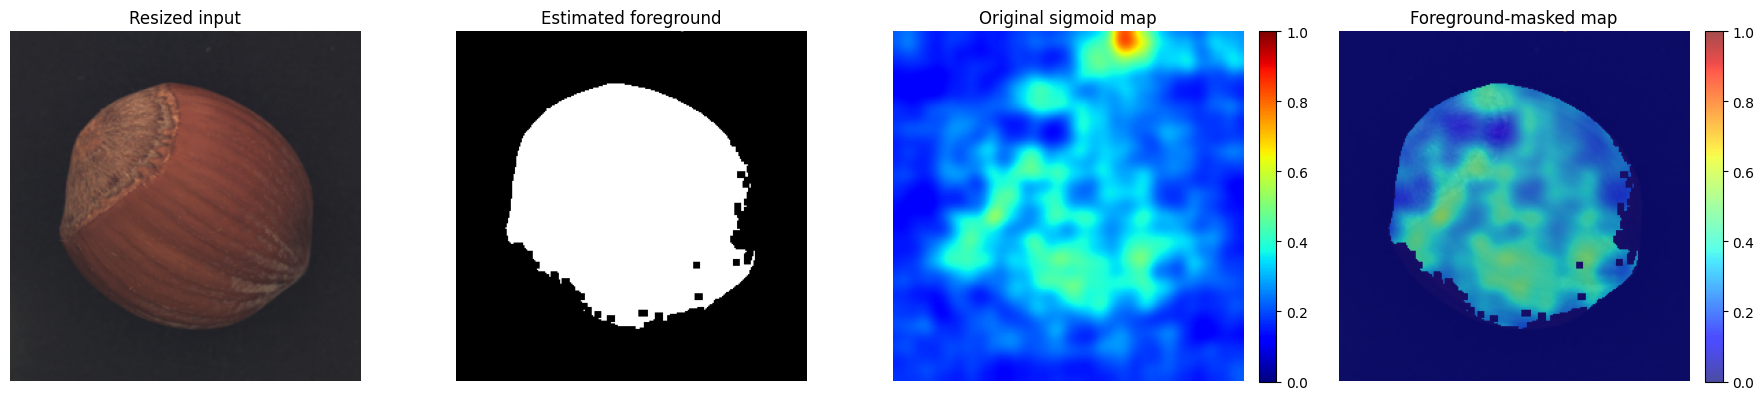

In [13]:
resized_pil = pil_image.resize((image_size, image_size))
resized_rgb = transforms.ToTensor()(resized_pil)

# Luma is more stable than plain RGB mean for dark backgrounds.
gray = 0.2126 * resized_rgb[0] + 0.7152 * resized_rgb[1] + 0.0722 * resized_rgb[2]

try:
    from skimage.filters import threshold_otsu

    foreground_threshold = float(threshold_otsu(gray.numpy()))
    threshold_source = "otsu"
except Exception:
    foreground_threshold = float(torch.quantile(gray.flatten(), 0.45).item())
    threshold_source = "q45 fallback"

foreground_mask = (gray > foreground_threshold).float()

# Remove tiny islands, but avoid aggressive closing: it can fill the whole dark background.
fg = foreground_mask[None, None]
fg = torch_f.max_pool2d(fg, kernel_size=5, stride=1, padding=2)
fg = 1.0 - torch_f.max_pool2d(1.0 - fg, kernel_size=5, stride=1, padding=2)
foreground_mask = fg.squeeze()
background_mask = 1.0 - foreground_mask

prob_map = prob_map_256.detach().cpu()
inside_values = prob_map[foreground_mask > 0.5]
outside_values = prob_map[background_mask > 0.5]


def describe_region(name, values):
    if values.numel() == 0:
        print(f"{name:14s} n=0 max=n/a mean=n/a")
        return
    print(f"{name:14s} n={values.numel()} max={values.max().item():.4f} mean={values.mean().item():.4f}")


print(f"threshold: {foreground_threshold:.4f} ({threshold_source})")
describe_region("inside object", inside_values)
describe_region("outside object", outside_values)

masked_prob_map = prob_map * foreground_mask

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(resized_pil)
axes[0].set_title("Resized input")
axes[0].axis("off")

axes[1].imshow(foreground_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Estimated foreground")
axes[1].axis("off")

heat = axes[2].imshow(prob_map, cmap="jet", vmin=0, vmax=1)
axes[2].set_title("Original sigmoid map")
axes[2].axis("off")
plt.colorbar(heat, ax=axes[2], fraction=0.046, pad=0.04)

axes[3].imshow(resized_pil)
heat = axes[3].imshow(masked_prob_map, cmap="jet", alpha=0.7, vmin=0, vmax=1)
axes[3].set_title("Foreground-masked map")
axes[3].axis("off")
plt.colorbar(heat, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 7. Quick checks

In [14]:
assert batch.shape == (1, 3, image_size, image_size)
assert raw_anomaly_map.shape[-2:] == prob_anomaly_map.shape[-2:]
assert torch.all((prob_anomaly_map >= 0) & (prob_anomaly_map <= 1))
assert torch.isfinite(raw_anomaly_map).all()
assert torch.isfinite(output.pred_score).all()

print("All basic checks passed.")

All basic checks passed.
